<a href="https://colab.research.google.com/github/dhruvi15/Machine-Learning-Lab-1/blob/main/Project_Smart_Health_%26_Lifestyle_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#_____________Activity Part 1 — Load & Explore Dataset_______________________
import pandas as pd

from google.colab import files
uploaded = files.upload()

df = pd.read_csv("project_health_dataset.csv")
# Preview
print(df.head())

# Info
print(df.info())

# Missing values
print(df.isnull().sum())

# Duplicates
print(df.duplicated().sum())

# Stats
print(df.describe())

Saving project_health_dataset.csv to project_health_dataset.csv
   Age  Gender  HoursExercise  HoursSleep  DietScore  StressLevel   BMI  \
0   56    Male             13           5          7            3  18.9   
1   46  Female              4           4          1            5  34.3   
2   32  Female              0           7          3            6  32.4   
3   25  Female              2           7          2            9  24.0   
4   38    Male              9           4          9            5  34.3   

   HealthScore  
0            0  
1            0  
2            1  
3            1  
4            0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            100 non-null    int64  
 1   Gender         100 non-null    object 
 2   HoursExercise  100 non-null    int64  
 3   HoursSleep     100 non-null    int64  
 4   DietScore  

# Observation:
# - Dataset has 500 rows
# - Missing values in BMI column
# - No duplicates

In [12]:
#_______Activity Part 2 — Data Cleaning & Feature Engineering_______

# Numerical
df.fillna(df.mean(numeric_only=True), inplace=True)

# Categorical
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

    # Remove duplicates

    df.drop_duplicates(inplace=True)

    # Create Features

    df['WellnessIndex'] = df['HoursExercise'] * df['HoursSleep']

    # BMI Category

    def bmi_category(bmi):
     if bmi < 18.5:
        return 'Underweight'
     elif bmi < 25:
        return 'Normal'
     elif bmi < 30:
        return 'Overweight'
     else:
        return 'Obese'

df['BMI_Category'] = df['BMI'].apply(bmi_category)

# Encode Categorical
df = pd.get_dummies(df, drop_first=True)

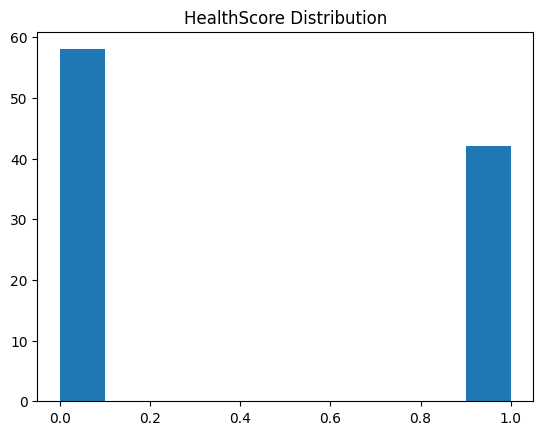

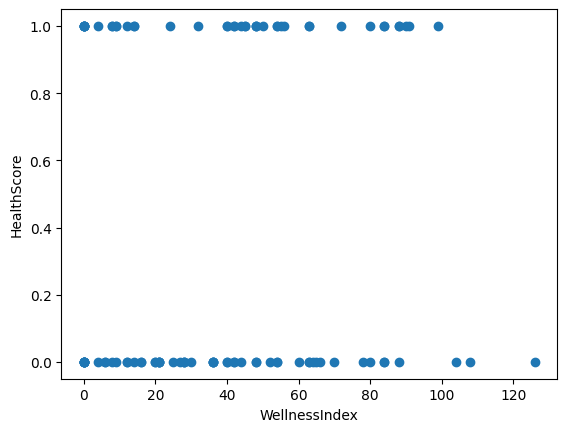

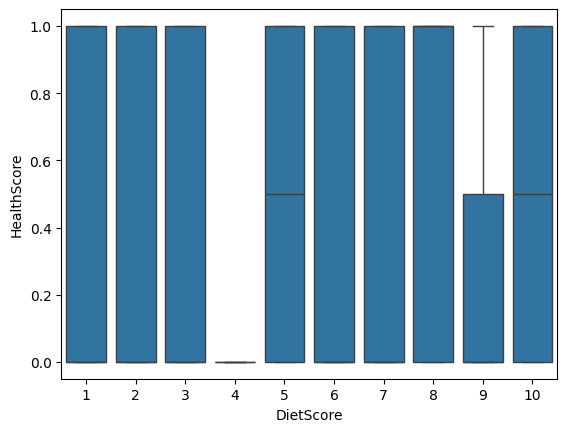

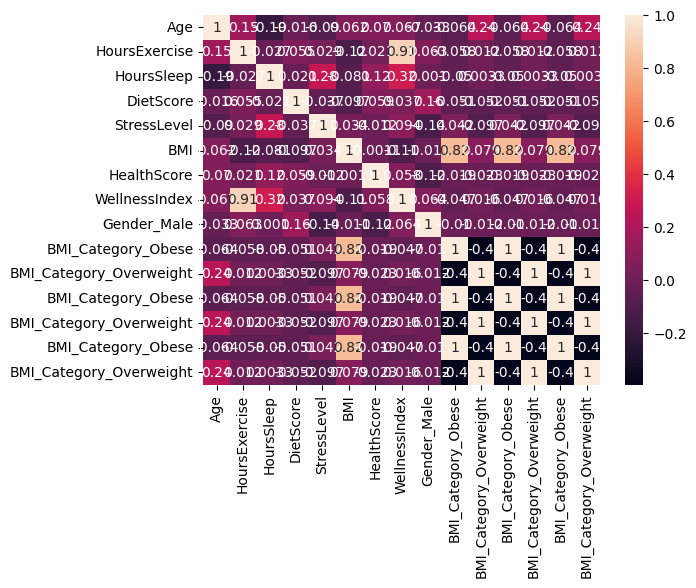

In [13]:
#______Activity Part 3 — Data Visualization_______

import matplotlib.pyplot as plt
import seaborn as sns

# 1 Histogram

plt.hist(df['HealthScore'])
plt.title('HealthScore Distribution')
plt.show()

# 2 Scatter

plt.scatter(df['WellnessIndex'], df['HealthScore'])
plt.xlabel('WellnessIndex')
plt.ylabel('HealthScore')
plt.show()

# 3 Boxplot

sns.boxplot(x='DietScore', y='HealthScore', data=df)
plt.show()

# 4 Heatmap

sns.heatmap(df.corr(), annot=True)
plt.show()


# - WellnessIndex increases HealthScore
# - Strong correlation between BMI and HealthScore

In [15]:
#____________________Activity Part 5 — Neural Network Programming________________________

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X = df.drop('HealthScore', axis=1)
y = df['HealthScore']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC



# 1. Logistic Regression

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# 2. Random Forest

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# 3. SVM

model = SVC()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# 4. KNN

model = KNeighborsClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.45
[[7 4]
 [7 2]]
              precision    recall  f1-score   support

           0       0.50      0.64      0.56        11
           1       0.33      0.22      0.27         9

    accuracy                           0.45        20
   macro avg       0.42      0.43      0.41        20
weighted avg       0.42      0.45      0.43        20

Random Forest Accuracy: 0.3
[[6 5]
 [9 0]]
              precision    recall  f1-score   support

           0       0.40      0.55      0.46        11
           1       0.00      0.00      0.00         9

    accuracy                           0.30        20
   macro avg       0.20      0.27      0.23        20
weighted avg       0.22      0.30      0.25        20

SVM Accuracy: 0.5
[[7 4]
 [6 3]]
              precision    recall  f1-score   support

           0       0.54      0.64      0.58        11
           1       0.43      0.33      0.38         9

    accuracy                           0.50        20
  